In [1]:
# %%
# Cell 1: Imports and Configuration Paths
import os
import shutil
import dask.dataframe as dd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.animation import FFMpegWriter, PillowWriter

# Attempt to configure ffmpeg via imageio-ffmpeg (no system install needed)
try:
    import imageio_ffmpeg
    ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
    plt.rcParams['animation.ffmpeg_path'] = ffmpeg_exe
    print(f"Configured ffmpeg executable: {ffmpeg_exe}")
except ImportError:
    print("imageio-ffmpeg not installed; will fallback to system 'ffmpeg'.")

# File paths
GEOMETRY_PATH = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_geometry.txt'
NSB_CSV_PATH = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/files-backup/high_pix_161097_CT_5_FULL.txt'
PARQUET_DIR   = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/nsb_parquet'

# Notebook parameters
BIN_WIDTH   = '5S'  # e.g. '10S', '30S', '1T'
OUTPUT_PATH = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_animation.mp4'
FPS         = 10

# %%
# Cell 2: Function Definitions

def convert_csv_to_parquet(csv_path=NSB_CSV_PATH, parquet_dir=PARQUET_DIR, blocksize='128MB'):
    """
    Read large NSB CSV once and write as Parquet for fast downstream reads.
    """
    if os.path.exists(parquet_dir):
        print(f"Parquet directory '{parquet_dir}' exists. Skipping.")
        return
    print("Reading CSV with Dask...")
    df = dd.read_csv(csv_path, sep=';', names=['pixel','nsb','time'], assume_missing=True,
                     blocksize=blocksize,
                     dtype={'pixel':'int64','nsb':'float64','time':'object'})
    df['time'] = df['time'].str.replace('UTC: ','', regex=False)
    df['time'] = dd.to_datetime(df['time'], utc=True)
    print(f"Writing to Parquet at '{parquet_dir}'...")
    df.to_parquet(parquet_dir, engine='pyarrow', write_index=False)
    print("CSV converted to Parquet.")


def aggregate_by_bin(bin_width, parquet_dir=PARQUET_DIR):
    """
    Load Parquet NSB data and aggregate mean nsb per pixel per time bin.
    Returns a pandas DataFrame.
    """
    print(f"Loading Parquet data from '{parquet_dir}'...")
    df = dd.read_parquet(parquet_dir, engine='pyarrow')
    df['tbin'] = df['time'].dt.floor(bin_width)
    print("Grouping and computing mean NSB per pixel-bin...")
    result = df.groupby(['tbin','pixel']).nsb.mean().reset_index()
    return result.compute()


def load_geometry(geometry_path=GEOMETRY_PATH):
    """
    Read pixel geometry into pandas DataFrame.
    """
    print(f"Loading geometry from '{geometry_path}'...")
    geom = pd.read_csv(geometry_path, sep=';', names=['pixel','x','y'])
    print(f"Loaded geometry: {len(geom)} pixels.")
    return geom


def make_animation(agg_df, geom_df, output_path, fps=2, figsize=(6,6)):
    """
    Create and save animation of pixel NSB over time bins.
    Generates both MP4 and GIF outputs.
    """
    print("Merging data...")
    df = agg_df.merge(geom_df, on='pixel')

    print("Pivoting data for animation...")
    pivot = df.pivot(index='pixel', columns='tbin', values='nsb')
    pixel_list = geom_df['pixel']
    pivot = pivot.reindex(index=pixel_list)
    xs = geom_df.set_index('pixel').loc[pixel_list,'x']
    ys = geom_df.set_index('pixel').loc[pixel_list,'y']
    times = sorted(pivot.columns)

    fig, ax = plt.subplots(figsize=figsize)
    scat = ax.scatter(
        xs, ys,
        c=pivot[times[0]].values,
        vmin=df['nsb'].min(), vmax=df['nsb'].max(),
        s=20, cmap='plasma',  # Changed to 'plasma' for better visibility
    )  # cmap changed to 'Reds'
    ax.set_aspect('equal')
    ax.axis('off')

    def update(i):
        scat.set_array(pivot[times[i]].values)
        ax.set_title(str(times[i]), fontsize=8)
        return scat,

    anim = FuncAnimation(fig, update, frames=len(times), blit=True)
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    # Save MP4
    mp4_path = output_path
    print(f"Saving MP4 to {mp4_path}...")
    writer_mp4 = FFMpegWriter(fps=fps, codec='h264', extra_args=['-pix_fmt','yuv420p'])
    anim.save(mp4_path, writer=writer_mp4)
    print("MP4 saved successfully.")

    # Save GIF
    gif_path = os.path.splitext(output_path)[0] + '.gif'
    print(f"Saving GIF to {gif_path}...")
    writer_gif = PillowWriter(fps=fps)
    anim.save(gif_path, writer=writer_gif)
    print("GIF saved successfully.")

# %%
# Cell 3: Execute Pipeline
convert_csv_to_parquet()
agg_df = aggregate_by_bin(BIN_WIDTH)
geom_df = load_geometry()
make_animation(agg_df, geom_df, OUTPUT_PATH, fps=FPS)

# %%
# Cell 4: Display Output Inline
from IPython.display import HTML

mp4 = OUTPUT_PATH
gif = os.path.splitext(OUTPUT_PATH)[0] + '.gif'
media_tags = []
if os.path.exists(mp4):
    media_tags.append(f'<video width=640 height=480 controls><source src="{mp4}" type="video/mp4"></video>')
if os.path.exists(gif):
    media_tags.append(f'<br><img src="{gif}" alt="Animation GIF"/>')

HTML("""
{tags}
""".format(tags=''.join(media_tags)))


Configured ffmpeg executable: /home/sghosh/.local/lib/python3.7/site-packages/imageio_ffmpeg/binaries/ffmpeg-linux64-v4.2.2
Parquet directory '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/nsb_parquet' exists. Skipping.
Loading Parquet data from '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/nsb_parquet'...
Grouping and computing mean NSB per pixel-bin...
Loading geometry from '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_geometry.txt'...
Loaded geometry: 1764 pixels.
Merging data...
Pivoting data for animation...
Saving MP4 to /lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_animation.mp4...
MP4 saved successfully.
Saving GIF to /lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_animation.gif...
GIF saved successfully.


In [2]:
# Single Cell: Full Pipeline with Track Detection & Flashcam Animation
import os
import dask.dataframe as dd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter

# Meteorite/Track tools
from flatfielding import FlatFieldModel
from functions_import_essential_novae import (
    get_typed_nn_pix,
    read_single_run_utc_cut,
    track_sorter
)
try:
    import imageio_ffmpeg
    ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
    plt.rcParams['animation.ffmpeg_path'] = ffmpeg_exe
    print(f"Configured ffmpeg executable: {ffmpeg_exe}")
except ImportError:
    print("imageio-ffmpeg not installed; falling back to system ffmpeg...")

# --- User Parameters ---
GEOMETRY_PATH = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_geometry.txt'
NSB_CSV_PATH = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/files-backup/high_pix_161097_CT_5_FULL.txt'
PARQUET_DIR   = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/nsb_parquet'
OUTPUT_BASE   = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_animation'

# Track finder parameters
RUN_NUMBER    = 161097     # pass into read_single_run_utc_cut
TEL_ID        = 5          # telescope ID for flat-field
DATE          = '2020-07-18'

# Animation parameters
BIN_WIDTH     = '30S'      # e.g. '10S', '30S', '1T'
FPS           = 10
TRACK_ID      = 0          # which track index to visualize
RADIUS        = 0.05       # neighbor radius in geometry units

# --- Step 0: Detect Tracks ---
fmodel = FlatFieldModel()
coeffs = fmodel.get_FlatField(pd.to_datetime(DATE), TEL_ID)
flat_lg = coeffs['Coefficient_lg']
typed_nn_pix = get_typed_nn_pix(TEL_ID)
pix, times_raw, brightness_raw = read_single_run_utc_cut(RUN_NUMBER)
tracks, possible_meteorites = track_sorter(pix, times_raw, brightness_raw, typed_nn_pix)
# Apply flat-field correction
tracks_flat = []
for pix_list, time_list, bright_list in tracks:
    C = np.array([flat_lg.loc[p] for p in pix_list], dtype=float)
    tracks_flat.append((pix_list, time_list, np.array(bright_list)/C))
print(f"Found {len(tracks)} tracks; using track {TRACK_ID}")
track_pixels = tracks_flat[TRACK_ID][0]

# --- Step 1: CSV -> Parquet (once) ---
def convert_csv_to_parquet():
    if os.path.exists(PARQUET_DIR): return
    df = dd.read_csv(NSB_CSV_PATH, sep=';', names=['pixel','nsb','time'], assume_missing=True,
                     blocksize='128MB', dtype={'pixel':'int64','nsb':'float64','time':'object'})
    df['time'] = df['time'].str.replace('UTC: ','', regex=False)
    df['time'] = dd.to_datetime(df['time'], utc=True)
    df.to_parquet(PARQUET_DIR, engine='pyarrow', write_index=False)
    print("Converted CSV to Parquet.")

# --- Step 2: Aggregate NSB by time bin ---
def aggregate_by_bin():
    df = dd.read_parquet(PARQUET_DIR, engine='pyarrow')
    df['tbin'] = df['time'].dt.floor(BIN_WIDTH)
    return df.groupby(['tbin','pixel']).nsb.mean().reset_index().compute()

# --- Step 3: Load geometry ---
def load_geometry():
    return pd.read_csv(GEOMETRY_PATH, sep=';', names=['pixel','x','y'])

# --- Step 4: Neighbor selection ---
def get_neighbors(pixel_ids, geom_df):
    coords = geom_df.set_index('pixel')[['x','y']]
    neigh = set(pixel_ids)
    for pid in pixel_ids:
        x0,y0 = coords.loc[pid]
        d = np.sqrt((coords.x-x0)**2 + (coords.y-y0)**2)
        neigh |= set(d[d<=RADIUS].index)
    return list(neigh)

# --- Execute pipeline and animate ---
convert_csv_to_parquet()
agg = aggregate_by_bin()
geom = load_geometry()
neighbors = get_neighbors(track_pixels, geom)
sub_geom = geom[geom.pixel.isin(neighbors)]
sub_agg = agg[agg.pixel.isin(neighbors)]
print(f"Animating track {TRACK_ID} with {len(neighbors)} pixels.")

# Pivot for plotting
df_merge = sub_agg.merge(sub_geom, on='pixel')
pivot = df_merge.pivot(index='pixel', columns='tbin', values='nsb')
pixels = sub_geom['pixel']
pivot = pivot.reindex(index=pixels)
xs = sub_geom.set_index('pixel').loc[pixels,'x']
ys = sub_geom.set_index('pixel').loc[pixels,'y']
times = sorted(pivot.columns)

# Build animation
fig, ax = plt.subplots(figsize=(6,6))
scat = ax.scatter(xs, ys, c=pivot[times[0]].values, vmin=df_merge.nsb.min(), vmax=df_merge.nsb.max(),
                  s=50, cmap='plasma')
ax.set_aspect('equal'); ax.axis('off')
def update(i):
    scat.set_array(pivot[times[i]].values)
    ax.set_title(str(times[i]),fontsize=8)
    return scat,
anim = FuncAnimation(fig, update, frames=len(times), blit=True)

# Save outputs
os.makedirs(os.path.dirname(OUTPUT_BASE), exist_ok=True)
mp4 = f"{OUTPUT_BASE}_track{TRACK_ID}.mp4"
print(f"Saving MP4: {mp4}")
anim.save(mp4, writer=FFMpegWriter(fps=FPS, codec='h264', extra_args=['-pix_fmt','yuv420p']))
gif = mp4.replace('.mp4','.gif')
print(f"Saving GIF: {gif}")
anim.save(gif, writer=PillowWriter(fps=FPS))

# Display inline
from IPython.display import HTML
media_html = []
if os.path.exists(mp4): media_html.append(f'<video width=640 controls><source src="{mp4}" type="video/mp4"></video>')
if os.path.exists(gif): media_html.append(f'<img src="{gif}"/>')
HTML(''.join(media_html))


path_eval is set to: "/lfs/l7/hess/users/sghosh/eval_high_data_utc/high_pixel"
path_eval_cut is set to: "/lfs/l7/hess/users/sghosh/eval_high_data_utc_cut/high_pixel"
Configured ffmpeg executable: /home/sghosh/.local/lib/python3.7/site-packages/imageio_ffmpeg/binaries/ffmpeg-linux64-v4.2.2
Reading high_pix_161097_CT_5_cut.h5...
/lfs/l7/hess/users/sghosh/eval_high_data_utc_cut/high_pixel/run161000-161199/161097/high_pix_161097_CT_5_cut.h5
read pix:
read time:
read brightness:
Found 4 tracks; using track 0
Animating track 0 with 19 pixels.
Saving MP4: /lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_animation_track0.mp4
Saving GIF: /lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_animation_track0.gif


In [5]:
# Single Cell: Full Pipeline with Track Detection & Flashcam Animation
import os
import dask.dataframe as dd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter

# Meteorite/Track tools
from flatfielding import FlatFieldModel
from functions_import_essential_novae import (
    get_typed_nn_pix,
    read_single_run_utc_cut,
    track_sorter
)
try:
    import imageio_ffmpeg
    ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
    plt.rcParams['animation.ffmpeg_path'] = ffmpeg_exe
    print(f"Configured ffmpeg executable: {ffmpeg_exe}")
except ImportError:
    print("imageio-ffmpeg not installed; falling back to system ffmpeg...")

# --- User Parameters ---
GEOMETRY_PATH = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_geometry.txt'
NSB_CSV_PATH = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/files-backup/high_pix_161097_CT_5_FULL.txt'
PARQUET_DIR   = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/nsb_parquet'
OUTPUT_BASE   = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_animation'

# Track finder parameters
RUN_NUMBER    = 161097     # pass into read_single_run_utc_cut
TEL_ID        = 5          # telescope ID for flat-field
DATE          = '2020-07-18'

# Animation parameters
BIN_WIDTH     = '30S'      # e.g. '10S', '30S', '1T'
FPS           = 2
TRACK_ID      = 0          # which track index to visualize
RADIUS        = 0.05       # neighbor radius in geometry units

# --- Step 0: Detect Tracks ---
fmodel = FlatFieldModel()
coeffs = fmodel.get_FlatField(pd.to_datetime(DATE), TEL_ID)
flat_lg = coeffs['Coefficient_lg']
typed_nn_pix = get_typed_nn_pix(TEL_ID)
pix, times_raw, brightness_raw = read_single_run_utc_cut(RUN_NUMBER)
tracks, possible_meteorites = track_sorter(pix, times_raw, brightness_raw, typed_nn_pix)
# Apply flat-field correction
tracks_flat = []
for pix_list, time_list, bright_list in tracks:
    C = np.array([flat_lg.loc[p] for p in pix_list], dtype=float)
    tracks_flat.append((pix_list, time_list, np.array(bright_list)/C))
print(f"Found {len(tracks)} tracks; using track {TRACK_ID}")
track_pixels = tracks_flat[TRACK_ID][0]

# --- Step 1: CSV -> Parquet (once) ---
def convert_csv_to_parquet():
    if os.path.exists(PARQUET_DIR): return
    df = dd.read_csv(NSB_CSV_PATH, sep=';', names=['pixel','nsb','time'], assume_missing=True,
                     blocksize='128MB', dtype={'pixel':'int64','nsb':'float64','time':'object'})
    df['time'] = df['time'].str.replace('UTC: ','', regex=False)
    df['time'] = dd.to_datetime(df['time'], utc=True)
    df.to_parquet(PARQUET_DIR, engine='pyarrow', write_index=False)
    print("Converted CSV to Parquet.")

# --- Step 2: Aggregate NSB by time bin ---
def aggregate_by_bin():
    df = dd.read_parquet(PARQUET_DIR, engine='pyarrow')
    df['tbin'] = df['time'].dt.floor(BIN_WIDTH)
    return df.groupby(['tbin','pixel']).nsb.mean().reset_index().compute()

# --- Step 3: Load geometry ---
def load_geometry():
    return pd.read_csv(GEOMETRY_PATH, sep=';', names=['pixel','x','y'])

# --- Step 4: Neighbor selection ---
def get_neighbors(pixel_ids, geom_df):
    coords = geom_df.set_index('pixel')[['x','y']]
    neigh = set(pixel_ids)
    for pid in pixel_ids:
        x0,y0 = coords.loc[pid]
        d = np.sqrt((coords.x-x0)**2 + (coords.y-y0)**2)
        neigh |= set(d[d<=RADIUS].index)
    return list(neigh)

# --- Execute pipeline and animate ---
convert_csv_to_parquet()
agg = aggregate_by_bin()
geom = load_geometry()
neighbors = get_neighbors(track_pixels, geom)
sub_geom = geom[geom.pixel.isin(neighbors)]
sub_agg = agg[agg.pixel.isin(neighbors)]
print(f"Animating track {TRACK_ID} with {len(neighbors)} pixels.")

# Pivot for plotting
df_merge = sub_agg.merge(sub_geom, on='pixel')
pivot = df_merge.pivot(index='pixel', columns='tbin', values='nsb')
pixels = sub_geom['pixel']
pivot = pivot.reindex(index=pixels)
xs = sub_geom.set_index('pixel').loc[pixels,'x']
ys = sub_geom.set_index('pixel').loc[pixels,'y']
times = sorted(pivot.columns)

# Build animation with flashcam geometry background
fig, ax = plt.subplots(figsize=(6,6))
# Plot full geometry as faint gray background
all_geom = load_geometry()
ax.scatter(all_geom['x'], all_geom['y'], c='lightgray', s=10, label='All pixels')

# Overlay track+neighbors brightness
scat = ax.scatter(
    xs, ys,
    c=pivot[times[0]].values,
    vmin=df_merge.nsb.min(), vmax=df_merge.nsb.max(),
    s=50, cmap='plasma', label='Track brightness'
)
ax.set_aspect('equal')
ax.axis('off')
ax.legend(loc='upper right', markerscale=2, fontsize='small')

def update(i):
    scat.set_array(pivot[times[i]].values)
    ax.set_title(str(times[i]), fontsize=8)
    return scat,

anim = FuncAnimation(fig, update, frames=len(times), blit=True)

# Save outputs
os.makedirs(os.path.dirname(OUTPUT_BASE), exist_ok=True)
mp4 = f"{OUTPUT_BASE}_track{TRACK_ID}.mp4"
print(f"Saving MP4: {mp4}")
anim.save(mp4, writer=FFMpegWriter(fps=FPS, codec='h264', extra_args=['-pix_fmt','yuv420p']))
gif = mp4.replace('.mp4','.gif')
print(f"Saving GIF: {gif}")
anim.save(gif, writer=PillowWriter(fps=FPS))

# Display inline
from IPython.display import HTML
media_html = []
if os.path.exists(mp4): media_html.append(f'<video width=640 controls><source src="{mp4}" type="video/mp4"></video>')
if os.path.exists(gif): media_html.append(f'<img src="{gif}"/>')
HTML(''.join(media_html))


Configured ffmpeg executable: /home/sghosh/.local/lib/python3.7/site-packages/imageio_ffmpeg/binaries/ffmpeg-linux64-v4.2.2
Reading high_pix_161097_CT_5_cut.h5...
/lfs/l7/hess/users/sghosh/eval_high_data_utc_cut/high_pixel/run161000-161199/161097/high_pix_161097_CT_5_cut.h5
read pix:
read time:
read brightness:
Found 4 tracks; using track 0
Animating track 0 with 19 pixels.
Saving MP4: /lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_animation_track0.mp4
Saving GIF: /lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_animation_track0.gif


In [21]:
# Single Cell: Flashcam Animation for a Specific Track using Nearest-Neighbor Map
import os
import dask.dataframe as dd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter

# Meteorite/Track tools
from flatfielding import FlatFieldModel
from functions_import_essential_novae import (
    get_typed_nn_pix,
    read_single_run_utc_cut,
    track_sorter
)

# Try to configure ffmpeg via imageio-ffmpeg
# Try to configure ffmpeg via imageio-ffmpeg
try:
    import imageio_ffmpeg
    ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
    plt.rcParams['animation.ffmpeg_path'] = ffmpeg_exe
    print(f"Configured ffmpeg: {ffmpeg_exe}")
except ImportError:
    print("imageio-ffmpeg not installed; using system ffmpeg if available.")
    print("imageio-ffmpeg not installed; using system ffmpeg if available.")

# --- User Parameters ---
GEOMETRY_PATH = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_geometry.txt'
NSB_CSV_PATH = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/files-backup/high_pix_161097_CT_5_FULL.txt'
PARQUET_DIR   = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/nsb_parquet'
OUTPUT_BASE   = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_animation'

# Track finder parameters
RUN_NUMBER    = 161097     # for read_single_run_utc_cut (updated)
TEL_ID        = 5          # telescope ID
DATE          = '2020-07-18'
TRACK_ID      = 0          # index of track to visualize

# Animation parameters
BIN_WIDTH     = '30S'      # pandas time offset alias (e.g. '10S', '30S', '1T')
FPS           = 2          # frames per second for output video

# --- 1) Detect & flat-field tracks ---
fmodel = FlatFieldModel()
coeffs = fmodel.get_FlatField(pd.to_datetime(DATE), TEL_ID)
flat_lg = coeffs['Coefficient_lg']
typed_nn_pix = get_typed_nn_pix(TEL_ID)
# Convert Numba typed list to Python list for indexing
typed_nn_pix = list(typed_nn_pix)

pix, times_raw, brightness_raw = read_single_run_utc_cut(RUN_NUMBER)
tracks, _ = track_sorter(pix, times_raw, brightness_raw, typed_nn_pix)

# Apply flat-field correction to brightness
tracks_flat = []
for pix_list, time_list, bright_list in tracks:
    C = np.array([flat_lg.loc[p] for p in pix_list], dtype=float)
    tracks_flat.append((pix_list, time_list, np.array(bright_list)/C))

print(f"Detected {len(tracks_flat)} tracks; visualizing track {TRACK_ID}.")
track_pixels = tracks_flat[TRACK_ID][0]

# --- 2) CSV -> Parquet (first run only) ---
def convert_csv_to_parquet():
    if os.path.exists(PARQUET_DIR):
        return
    df = dd.read_csv(NSB_CSV_PATH, sep=';', names=['pixel','nsb','time'],
                     assume_missing=True, blocksize='128MB',
                     dtype={'pixel':'int64','nsb':'float64','time':'object'})
    df['time'] = df['time'].str.replace('UTC: ', '', regex=False)
    df['time'] = dd.to_datetime(df['time'], utc=True)
    df.to_parquet(PARQUET_DIR, engine='pyarrow', write_index=False)
    print("Converted CSV to Parquet.")

# --- 3) Aggregate NSB by time bins ---
def aggregate_by_bin():
    df = dd.read_parquet(PARQUET_DIR, engine='pyarrow')
    df['tbin'] = df['time'].dt.floor(BIN_WIDTH)
    return df.groupby(['tbin','pixel']).nsb.mean().reset_index().compute()

# --- 4) Load flashcam geometry ---
def load_geometry():
    return pd.read_csv(GEOMETRY_PATH, sep=';', names=['pixel','x','y'])

# --- 5) Get nearest-neighbors for track pixels ---
# Cast track pixel IDs to integers
track_pixels = [int(p) for p in track_pixels]
neighbors = set(track_pixels)
for pid in track_pixels:
    neighbors.update(typed_nn_pix[pid])
neighbors = list(neighbors)
print(f"Track has {len(track_pixels)} pixels; including {len(neighbors)-len(track_pixels)} neighbors = {len(neighbors)} total.")

# --- 6) Run pipeline and subset data ---


Configured ffmpeg: /home/sghosh/.local/lib/python3.7/site-packages/imageio_ffmpeg/binaries/ffmpeg-linux64-v4.2.2
Reading high_pix_161097_CT_5_cut.h5...
/lfs/l7/hess/users/sghosh/eval_high_data_utc_cut/high_pixel/run161000-161199/161097/high_pix_161097_CT_5_cut.h5
read pix:
read time:
read brightness:
Detected 4 tracks; visualizing track 0.
Track has 53225 pixels; including -53175 neighbors = 50 total.


In [23]:
# Single Cell: Flashcam Animation for a Specific Track using Nearest-Neighbor Map
import os
import dask.dataframe as dd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter

# Meteorite/Track tools
from flatfielding import FlatFieldModel
from functions_import_essential_novae import (
    get_typed_nn_pix,
    read_single_run_utc_cut,
    track_sorter
)

# Try to configure ffmpeg via imageio-ffmpeg
try:
    import imageio_ffmpeg
    ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
    plt.rcParams['animation.ffmpeg_path'] = ffmpeg_exe
    print(f"Configured ffmpeg: {ffmpeg_exe}")
except ImportError:
    print("imageio-ffmpeg not installed; using system ffmpeg if available.")

# --- User Parameters ---
GEOMETRY_PATH = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_geometry.txt'
NSB_CSV_PATH  = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/files-backup/high_pix_161097_CT_5_FULL.txt'
PARQUET_DIR   = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/nsb_parquet'
OUTPUT_BASE   = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_animation'

# Track finder parameters
RUN_NUMBER    = 161097     # for read_single_run_utc_cut
TEL_ID        = 5          # telescope ID
DATE          = '2020-07-18'
TRACK_ID      = 0          # index of track to visualize

# Animation parameters
BIN_WIDTH     = '30S'      # pandas offset alias: '10S','30S','1T'
FPS           = 10         # frames per second

# --- 1) Detect & flat-field tracks ---
fmodel = FlatFieldModel()
coeffs = fmodel.get_FlatField(pd.to_datetime(DATE), TEL_ID)
flat_lg = coeffs['Coefficient_lg']
typed_nn_pix = get_typed_nn_pix(TEL_ID)
# Convert Numba typed list to Python list for indexing
typed_nn_pix = list(typed_nn_pix)
print(f"Loaded nearest-neighbor map for telescope {TEL_ID}, total pixels: {len(typed_nn_pix)}")

pix, times_raw, brightness_raw = read_single_run_utc_cut(RUN_NUMBER)
tracks, _ = track_sorter(pix, times_raw, brightness_raw, typed_nn_pix)

# Apply flat-field correction to brightness
tracks_flat = []
for pix_list, time_list, bright_list in tracks:
    C = np.array([flat_lg.loc[int(p)] for p in pix_list], dtype=float)
    tracks_flat.append((pix_list, time_list, np.array(bright_list)/C))

print(f"Detected {len(tracks_flat)} tracks; visualizing track {TRACK_ID}.")
track_pixels = tracks_flat[TRACK_ID][0]
track_pixels = [int(p) for p in track_pixels]

# --- 2) CSV -> Parquet (first run) ---
def convert_csv_to_parquet():
    if os.path.exists(PARQUET_DIR):
        return
    df = dd.read_csv(
        NSB_CSV_PATH, sep=';', names=['pixel','nsb','time'],
        assume_missing=True, blocksize='128MB',
        dtype={'pixel':'int64','nsb':'float64','time':'object'}
    )
    df['time'] = df['time'].str.replace('UTC: ', '', regex=False)
    df['time'] = dd.to_datetime(df['time'], utc=True)
    df.to_parquet(PARQUET_DIR, engine='pyarrow', write_index=False)
    print("Converted CSV to Parquet.")

# --- 3) Aggregate NSB by time bin ---
def aggregate_by_bin():
    df = dd.read_parquet(PARQUET_DIR, engine='pyarrow')
    df['tbin'] = df['time'].dt.floor(BIN_WIDTH)
    return df.groupby(['tbin','pixel']).nsb.mean().reset_index().compute()

# --- 4) Load flashcam geometry ---
def load_geometry():
    return pd.read_csv(GEOMETRY_PATH, sep=';', names=['pixel','x','y'])

# --- 5) Determine neighbor pixels ---
neighbors = set(track_pixels)
for pid in track_pixels:
    neighbors.update(typed_nn_pix[pid])
neighbors = list(neighbors)
print(f"Track has {len(track_pixels)} pixels; +{len(neighbors)-len(track_pixels)} neighbors = {len(neighbors)} total.")

# --- 6) Run pipeline and subset data ---
convert_csv_to_parquet()
agg_df = aggregate_by_bin()
geom_df = load_geometry()
sub_geom = geom_df[geom_df.pixel.isin(neighbors)]
sub_agg  = agg_df[agg_df.pixel.isin(neighbors)]

df_merge = sub_agg.merge(sub_geom, on='pixel')
pivot   = df_merge.pivot(index='pixel', columns='tbin', values='nsb')
pixels  = sub_geom['pixel']
pivot   = pivot.reindex(index=pixels)
xs      = sub_geom.set_index('pixel').loc[pixels,'x']
ys      = sub_geom.set_index('pixel').loc[pixels,'y']
times   = sorted(pivot.columns)

# --- 7) Build animation with full geometry background ---
fig, ax = plt.subplots(figsize=(6,6))
all_geom = load_geometry()
ax.scatter(all_geom['x'], all_geom['y'], c='lightgray', s=10)
scat = ax.scatter(
    xs, ys,
    c=pivot[times[0]].values,
    vmin=df_merge.nsb.min(), vmax=df_merge.nsb.max(),
    s=20, cmap='plasma'
)
ax.set_aspect('equal')
ax.axis('off')

def update(i):
    scat.set_array(pivot[times[i]].values)
    ax.set_title(str(times[i]), fontsize=8)
    return scat,

anim = FuncAnimation(fig, update, frames=len(times), blit=True)

# Ensure output dirs
os.makedirs(os.path.dirname(OUTPUT_BASE), exist_ok=True)
mp4 = f"{OUTPUT_BASE}_track{TRACK_ID}.mp4"
print(f"Saving MP4: {mp4}")
anim.save(mp4, writer=FFMpegWriter(fps=FPS, codec='h264', extra_args=['-pix_fmt','yuv420p']))

gif = mp4.replace('.mp4', '.gif')
print(f"Saving GIF: {gif}")
anim.save(gif, writer=PillowWriter(fps=FPS))

# --- 8) Display inline ---
from IPython.display import HTML
html = []
if os.path.exists(mp4): html.append(f'<video width=640 controls><source src="{mp4}" type="video/mp4"></video>')
if os.path.exists(gif): html.append(f'<img src="{gif}"/>')
HTML(''.join(html))


Configured ffmpeg: /home/sghosh/.local/lib/python3.7/site-packages/imageio_ffmpeg/binaries/ffmpeg-linux64-v4.2.2
Loaded nearest-neighbor map for telescope 5, total pixels: 1764
Reading high_pix_161097_CT_5_cut.h5...
/lfs/l7/hess/users/sghosh/eval_high_data_utc_cut/high_pixel/run161000-161199/161097/high_pix_161097_CT_5_cut.h5
read pix:
read time:
read brightness:
Detected 4 tracks; visualizing track 0.
Track has 53225 pixels; +-53175 neighbors = 50 total.
Saving MP4: /lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_animation_track0.mp4
Saving GIF: /lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_animation_track0.gif


Configured ffmpeg: /home/sghosh/.local/lib/python3.7/site-packages/imageio_ffmpeg/binaries/ffmpeg-linux64-v4.2.2
Loaded nearest-neighbor map for telescope 5, total pixels: 1764
Reading high_pix_161097_CT_5_cut.h5...
/lfs/l7/hess/users/sghosh/eval_high_data_utc_cut/high_pixel/run161000-161199/161097/high_pix_161097_CT_5_cut.h5
read pix:
read time:
read brightness:
Detected 4 tracks; visualizing track 0.
Track has 53225 pixels; +-53175 neighbors = 50 total.
Saving MP4: /lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_animation_track0.mp4
Saving GIF: /lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_animation_track0.gif


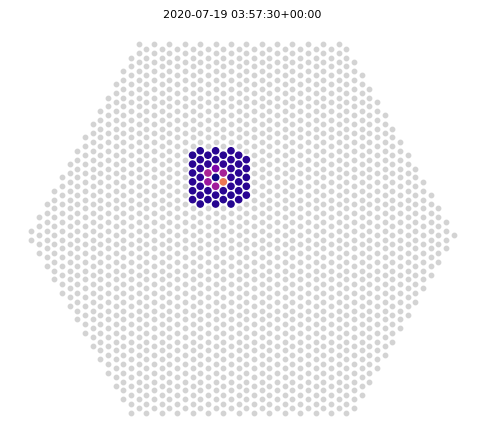

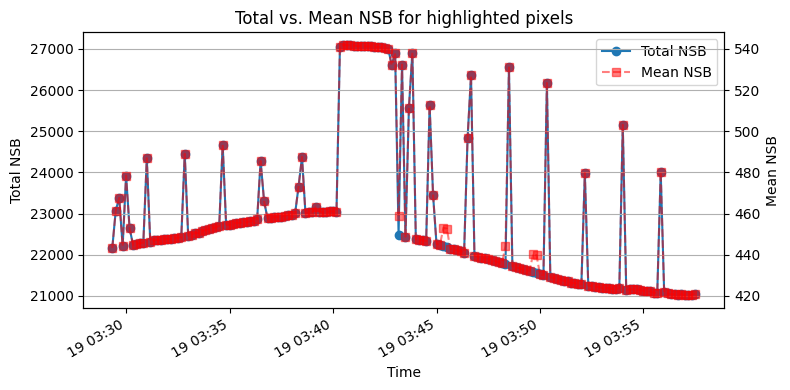

In [37]:
# Single Cell: Flashcam Animation for a Specific Track using Nearest-Neighbor Map
import os
import dask.dataframe as dd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter

# Meteorite/Track tools
from flatfielding import FlatFieldModel
from functions_import_essential_novae import (
    get_typed_nn_pix,
    read_single_run_utc_cut,
    track_sorter
)

# Try to configure ffmpeg via imageio-ffmpeg
try:
    import imageio_ffmpeg
    ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
    plt.rcParams['animation.ffmpeg_path'] = ffmpeg_exe
    print(f"Configured ffmpeg: {ffmpeg_exe}")
except ImportError:
    print("imageio-ffmpeg not installed; using system ffmpeg if available.")

# --- User Parameters ---
GEOMETRY_PATH = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_geometry.txt'
NSB_CSV_PATH  = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/files-backup/high_pix_161097_CT_5_FULL.txt'
PARQUET_DIR   = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/nsb_parquet'
OUTPUT_BASE   = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_animation'

# Track finder parameters
RUN_NUMBER    = 161097     # for read_single_run_utc_cut
TEL_ID        = 5          # telescope ID
DATE          = '2020-07-18'
TRACK_ID      = 0          # index of track to visualize

# Animation parameters
BIN_WIDTH     = '10S'      # pandas offset alias: '10S','30S','1T'
FPS           = 10         # frames per second

# --- 1) Detect & flat-field tracks ---
fmodel = FlatFieldModel()
coeffs = fmodel.get_FlatField(pd.to_datetime(DATE), TEL_ID)
flat_lg = coeffs['Coefficient_lg']
typed_nn_pix = get_typed_nn_pix(TEL_ID)
# Convert Numba typed list to Python list for indexing
typed_nn_pix = list(typed_nn_pix)
print(f"Loaded nearest-neighbor map for telescope {TEL_ID}, total pixels: {len(typed_nn_pix)}")

pix, times_raw, brightness_raw = read_single_run_utc_cut(RUN_NUMBER)
tracks, _ = track_sorter(pix, times_raw, brightness_raw, typed_nn_pix)

# Apply flat-field correction to brightness
tracks_flat = []
for pix_list, time_list, bright_list in tracks:
    C = np.array([flat_lg.loc[int(p)] for p in pix_list], dtype=float)
    tracks_flat.append((pix_list, time_list, np.array(bright_list)/C))

print(f"Detected {len(tracks_flat)} tracks; visualizing track {TRACK_ID}.")
track_pixels = tracks_flat[TRACK_ID][0]
track_pixels = [int(p) for p in track_pixels]

# --- 2) CSV -> Parquet (first run) ---
def convert_csv_to_parquet():
    if os.path.exists(PARQUET_DIR):
        return
    df = dd.read_csv(
        NSB_CSV_PATH, sep=';', names=['pixel','nsb','time'],
        assume_missing=True, blocksize='128MB',
        dtype={'pixel':'int64','nsb':'float64','time':'object'}
    )
    df['time'] = df['time'].str.replace('UTC: ', '', regex=False)
    df['time'] = dd.to_datetime(df['time'], utc=True)
    df.to_parquet(PARQUET_DIR, engine='pyarrow', write_index=False)
    print("Converted CSV to Parquet.")

# --- 3) Aggregate NSB by time bin ---
def aggregate_by_bin():
    df = dd.read_parquet(PARQUET_DIR, engine='pyarrow')
    df['tbin'] = df['time'].dt.floor(BIN_WIDTH)
    return df.groupby(['tbin','pixel']).nsb.mean().reset_index().compute()

# --- 4) Load flashcam geometry ---
def load_geometry():
    return pd.read_csv(GEOMETRY_PATH, sep=';', names=['pixel','x','y'])

# --- 5) Determine neighbor pixels ---
neighbors = set(track_pixels)
for pid in track_pixels:
    neighbors.update(typed_nn_pix[pid])
neighbors = list(neighbors)
print(f"Track has {len(track_pixels)} pixels; +{len(neighbors)-len(track_pixels)} neighbors = {len(neighbors)} total.")

# --- 6) Run pipeline and subset data ---
convert_csv_to_parquet()
agg_df = aggregate_by_bin()
geom_df = load_geometry()
sub_geom = geom_df[geom_df.pixel.isin(neighbors)]
sub_agg  = agg_df[agg_df.pixel.isin(neighbors)]

df_merge = sub_agg.merge(sub_geom, on='pixel')
pivot   = df_merge.pivot(index='pixel', columns='tbin', values='nsb')
pixels  = sub_geom['pixel']
pivot   = pivot.reindex(index=pixels)
xs      = sub_geom.set_index('pixel').loc[pixels,'x']
ys      = sub_geom.set_index('pixel').loc[pixels,'y']
times   = sorted(pivot.columns)

# --- 7) Build animation with full geometry background ---
fig, ax = plt.subplots(figsize=(6,6))
all_geom = load_geometry()
ax.scatter(all_geom['x'], all_geom['y'], c='lightgray', s=10)
scat = ax.scatter(
    xs, ys,
    c=pivot[times[0]].values,
    vmin=df_merge.nsb.min(), vmax=df_merge.nsb.max(),
    s=20, cmap='plasma'
)
ax.set_aspect('equal')
ax.axis('off')

def update(i):
    scat.set_array(pivot[times[i]].values)
    ax.set_title(str(times[i]), fontsize=8)
    return scat,

anim = FuncAnimation(fig, update, frames=len(times), blit=True)

# Ensure output dirs
os.makedirs(os.path.dirname(OUTPUT_BASE), exist_ok=True)
mp4 = f"{OUTPUT_BASE}_track{TRACK_ID}.mp4"
print(f"Saving MP4: {mp4}")
anim.save(mp4, writer=FFMpegWriter(fps=FPS, codec='h264', extra_args=['-pix_fmt','yuv420p']))

gif = mp4.replace('.mp4', '.gif')
print(f"Saving GIF: {gif}")
anim.save(gif, writer=PillowWriter(fps=FPS))

# --- 8) Plot binned light-curves: total  +  mean --------------------------------
# Aggregate both the sum and mean per 10-s bin
lc_stats = (
    sub_agg
    .groupby('tbin')
    .nsb
    .agg(['sum', 'mean'])   # two columns: ‘sum’ and ‘mean’
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(8, 4))

# Total NSB  – left y-axis
ax1.plot(lc_stats['tbin'], lc_stats['sum'],
         marker='o', linestyle='-', label='Total NSB')
ax1.set_xlabel('Time')
ax1.set_ylabel('Total NSB')
ax1.tick_params(axis='y')
ax1.set_title('Total vs. Mean NSB for highlighted pixels')

# Mean NSB  – right y-axis (so the scales don’t fight each other)
ax2 = ax1.twinx()
ax2.plot(lc_stats['tbin'], lc_stats['mean'],
         marker='s', linestyle='--', label='Mean NSB', color='red', alpha=0.5)
ax2.set_ylabel('Mean NSB')
ax2.tick_params(axis='y')

# Shared legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

fig.autofmt_xdate()  # rotate tick labels nicely
plt.grid(True)
plt.tight_layout()
plt.show()


# --- 9) Display inline ---
from IPython.display import HTML
html = []
if os.path.exists(mp4): html.append(f'<video width=640 controls><source src="{mp4}" type="video/mp4"></video>')
if os.path.exists(gif): html.append(f'<img src="{gif}"/>')
HTML(''.join(html))


Configured ffmpeg: /home/sghosh/.local/lib/python3.7/site-packages/imageio_ffmpeg/binaries/ffmpeg-linux64-v4.2.2
Loaded nearest-neighbor map for telescope 5, total pixels: 1764
Reading high_pix_161097_CT_5_cut.h5...
/lfs/l7/hess/users/sghosh/eval_high_data_utc_cut/high_pixel/run161000-161199/161097/high_pix_161097_CT_5_cut.h5
read pix:
read time:
read brightness:
Detected 4 tracks; visualizing track 0.
Track has 53225 pixels; +-53175 neighbors = 50 total.
Saving MP4: /lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_animation_track0.mp4
Saving GIF: /lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_animation_track0.gif


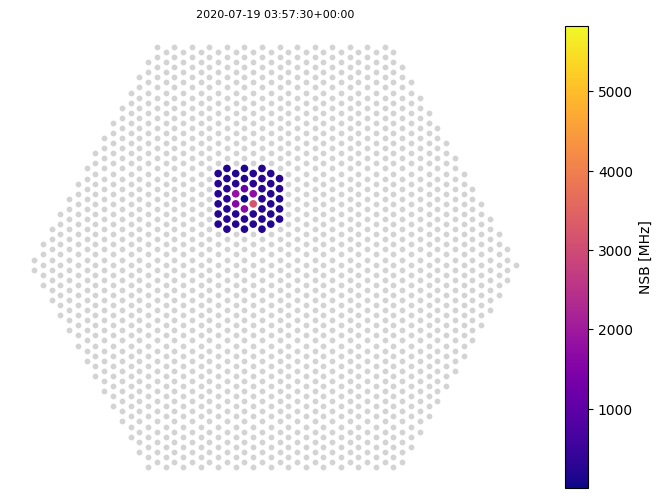

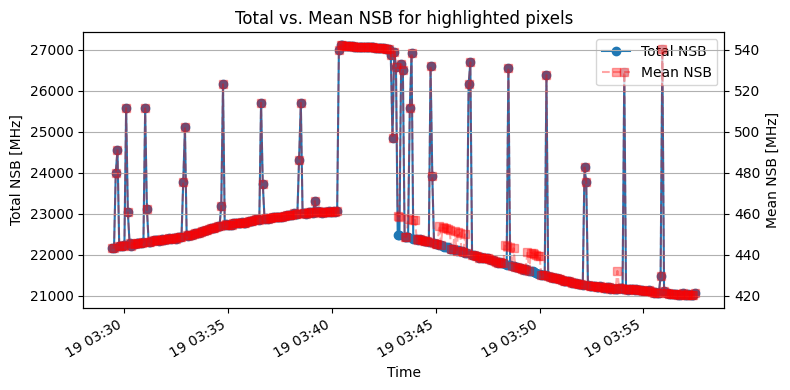

In [6]:
import os
import dask.dataframe as dd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter

# Meteorite/Track tools
from flatfielding import FlatFieldModel
from functions_import_essential_novae import (
    get_typed_nn_pix,
    read_single_run_utc_cut,
    track_sorter
)

# Try to configure ffmpeg via imageio-ffmpeg
try:
    import imageio_ffmpeg
    ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
    plt.rcParams['animation.ffmpeg_path'] = ffmpeg_exe
    print(f"Configured ffmpeg: {ffmpeg_exe}")
except ImportError:
    print("imageio-ffmpeg not installed; using system ffmpeg if available.")

# --- User Parameters ---
GEOMETRY_PATH = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_geometry.txt'
NSB_CSV_PATH  = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/files-backup/high_pix_161097_CT_5_FULL.txt'
PARQUET_DIR   = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/nsb_parquet'
OUTPUT_BASE   = '/lfs/l7/hess/users/sghosh/projects/Satellite-trails/flashcam_animation'

# Track finder parameters
RUN_NUMBER    = 161097     # for read_single_run_utc_cut
TEL_ID        = 5          # telescope ID
DATE          = '2020-07-18'
TRACK_ID      = 0          # index of track to visualize

# Animation parameters
BIN_WIDTH     = '5S'      # pandas offset alias: '10S','30S','1T'
FPS           = 10         # frames per second

# --- 1) Detect & flat-field tracks ---
fmodel = FlatFieldModel()
coeffs = fmodel.get_FlatField(pd.to_datetime(DATE), TEL_ID)
flat_lg = coeffs['Coefficient_lg']
typed_nn_pix = get_typed_nn_pix(TEL_ID)
typed_nn_pix = list(typed_nn_pix)
print(f"Loaded nearest-neighbor map for telescope {TEL_ID}, total pixels: {len(typed_nn_pix)}")

pix, times_raw, brightness_raw = read_single_run_utc_cut(RUN_NUMBER)
tracks, _ = track_sorter(pix, times_raw, brightness_raw, typed_nn_pix)

tracks_flat = []
for pix_list, time_list, bright_list in tracks:
    C = np.array([flat_lg.loc[int(p)] for p in pix_list], dtype=float)
    tracks_flat.append((pix_list, time_list, np.array(bright_list)/C))

print(f"Detected {len(tracks_flat)} tracks; visualizing track {TRACK_ID}.")
track_pixels = [int(p) for p in tracks_flat[TRACK_ID][0]]

# --- 2) CSV -> Parquet (first run) ---
def convert_csv_to_parquet():
    if os.path.exists(PARQUET_DIR):
        return
    df = dd.read_csv(
        NSB_CSV_PATH, sep=';', names=['pixel','nsb','time'],
        assume_missing=True, blocksize='128MB',
        dtype={'pixel':'int64','nsb':'float64','time':'object'}
    )
    df['time'] = df['time'].str.replace('UTC: ', '', regex=False)
    df['time'] = dd.to_datetime(df['time'], utc=True)
    df.to_parquet(PARQUET_DIR, engine='pyarrow', write_index=False)
    print("Converted CSV to Parquet.")

# --- 3) Aggregate NSB by time bin ---
def aggregate_by_bin():
    df = dd.read_parquet(PARQUET_DIR, engine='pyarrow')
    df['tbin'] = df['time'].dt.floor(BIN_WIDTH)
    return df.groupby(['tbin','pixel']).nsb.mean().reset_index().compute()

# --- 4) Load flashcam geometry ---
def load_geometry():
    return pd.read_csv(GEOMETRY_PATH, sep=';', names=['pixel','x','y'])

# --- 5) Determine neighbor pixels ---
neighbors = set(track_pixels)
for pid in track_pixels:
    neighbors.update(typed_nn_pix[pid])
neighbors = list(neighbors)
print(f"Track has {len(track_pixels)} pixels; +{len(neighbors)-len(track_pixels)} neighbors = {len(neighbors)} total.")

# --- 6) Run pipeline and subset data ---
convert_csv_to_parquet()
agg_df  = aggregate_by_bin()
geom_df = load_geometry()
sub_geom = geom_df[geom_df.pixel.isin(neighbors)]
sub_agg  = agg_df[agg_df.pixel.isin(neighbors)]

df_merge = sub_agg.merge(sub_geom, on='pixel')
pivot    = df_merge.pivot(index='pixel', columns='tbin', values='nsb')
pixels   = sub_geom['pixel']
pivot    = pivot.reindex(index=pixels)
xs       = sub_geom.set_index('pixel').loc[pixels,'x']
ys       = sub_geom.set_index('pixel').loc[pixels,'y']
times    = sorted(pivot.columns)

# --- 7) Build animation with full geometry background (with colorbar) ---
fig, ax = plt.subplots(figsize=(8,6))
all_geom = load_geometry()
ax.scatter(all_geom['x'], all_geom['y'], c='lightgray', s=10)

scat = ax.scatter(
    xs, ys,
    c=pivot[times[0]].values,
    vmin=df_merge.nsb.min(), vmax=df_merge.nsb.max(),
    s=20, cmap='plasma'
)

# add a colorbar for NSB
cbar = fig.colorbar(scat, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('NSB [MHz]')

ax.set_aspect('equal')
ax.axis('off')

def update(i):
    scat.set_array(pivot[times[i]].values)
    ax.set_title(str(times[i]), fontsize=8)
    return scat,

anim = FuncAnimation(fig, update, frames=len(times), blit=True)

# Ensure output dirs
os.makedirs(os.path.dirname(OUTPUT_BASE), exist_ok=True)
mp4 = f"{OUTPUT_BASE}_track{TRACK_ID}.mp4"
print(f"Saving MP4: {mp4}")
anim.save(mp4, writer=FFMpegWriter(fps=FPS, codec='h264', extra_args=['-pix_fmt','yuv420p']))

gif = mp4.replace('.mp4', '.gif')
print(f"Saving GIF: {gif}")
anim.save(gif, writer=PillowWriter(fps=FPS))

# --- 8) Plot binned light-curves: total  +  mean -------------------------------
lc_stats = (
    sub_agg
    .groupby('tbin')
    .nsb
    .agg(['sum', 'mean'])
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(lc_stats['tbin'], lc_stats['sum'],
         marker='o', linestyle='-', label='Total NSB')
ax1.set_xlabel('Time')
ax1.set_ylabel('Total NSB [MHz]')
ax1.set_title('Total vs. Mean NSB for highlighted pixels')

ax2 = ax1.twinx()
ax2.plot(lc_stats['tbin'], lc_stats['mean'],
         marker='s', linestyle='--', label='Mean NSB', color='red', alpha=0.35)
ax2.set_ylabel('Mean NSB [MHz]')
ax2.tick_params(axis='y')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

fig.autofmt_xdate()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 9) Display inline ---
from IPython.display import HTML
html = []
if os.path.exists(mp4):
    html.append(f'<video width=640 controls><source src="{mp4}" type="video/mp4"></video>')
if os.path.exists(gif):
    html.append(f'<img src="{gif}"/>')
HTML(''.join(html))
